# Train2 단독 분석 — KSPHM-KIMM 2026

> **역할 분담**: 본 노트북은 4개 Train 중 **Train2** 한 세트만 깊이 있게 분석합니다.
> 전체 4 Train 비교는 [00_walkthrough.ipynb](00_walkthrough.ipynb)를 참고.

## Train2 한눈에 (객관 측정)

| 항목 | 값 |
|---|---|
| 시험 시간 | 18.9 h (Operation 6,796행 × 10초) |
| 진동 파일 수 | 114 (10분 주기 × 1분 측정) |
| 종료 토크 | -21.01 Nm (자동 정지 트리거 -20 Nm) |
| TC SP Front max | 108.9 °C |
| TC SP Rear max | **180.6 °C** ← 더 뜨거운 쪽 |
| 시험 정지 원인 | 토크 트리거 (200°C 미도달) |
| best Spearman ρ feature | **CH3 RMS = 0.84** |
| 가장 큰 envelope 비율 | **CH3 BSF 1x = 28.3×** |
| 특이 사항 1 | CH4 late Kurtosis = **4159** (단발 거대 transient) |
| 특이 사항 2 | CH2/CH3/CH4 모두 **kurtogram fallback BP** (3/4 채널) |

## 분석 흐름

1. 데이터 인벤토리 + Operation 시그널
2. 4채널 시간영역 트렌드 (RMS/Kurt)
3. Early vs Late 상세 비교
4. Kurtogram 기반 BP + Envelope 분석
5. BPFx 라인의 late/early 비율 (객관 측정)
6. Train2 Health Index (PCA / SVM / Ensemble)
7. Spearman 상관 — RUL 회귀 후보
8. Train2 핵심 발견 + 모델링 메모

---

## 0. 환경 설정

In [1]:
import sys
from pathlib import Path

ROOT = Path('c:/Users/User/WorkSpace/data_challenge')
for p in (ROOT, ROOT / 'utils'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert
import scipy.stats as ss

from src.io_tdms import FS, CHANNEL_NAMES, load_tdms_file, tdms_to_array
from src.operation import load_operation, list_vibration_files, align_to_vibration

TR = 2  # focus on Train2 only
FEAT_DIR = ROOT / 'outputs' / 'features_utils'
print(f'분석 대상: Train{TR}')
print(f'numpy/pandas: {np.__version__} / {pd.__version__}')

분석 대상: Train2
numpy/pandas: 2.3.5 / 2.3.3


---

## 1. Train2 데이터 인벤토리

In [2]:
files = list_vibration_files(TR)
op = load_operation(TR)

print(f'진동 파일 수: {len(files)}  ({files[0].name} ~ {files[-1].name})')
print(f'TDMS 1개 크기: {files[0].stat().st_size/1024/1024:.2f} MB')
print(f'Operation 행수: {len(op):,}  (10초 간격, 0.1 Hz)')
print(f'시험 시간: {op["Time[sec]"].iloc[-1]/3600:.2f} h')
print()
print('Operation 컬럼별 통계:')
op[['Torque[Nm]', 'Motor speed[rpm]', 'TC SP Front', 'TC SP Rear']].describe().round(2)

진동 파일 수: 114  (000001.tdms ~ 000114.tdms)
TDMS 1개 크기: 23.44 MB
Operation 행수: 6,796  (10초 간격, 0.1 Hz)
시험 시간: 18.88 h

Operation 컬럼별 통계:


,Torque[Nm],Motor speed[rpm],TC SP Front,TC SP Rear
count,6796.00,6796.00,6796.00,6796.00
mean,-5.96,847.52,67.95,103.79
std,4.09,119.98,16.63,32.17
min,-21.01,491.00,15.82,15.79
25%,-10.16,730.00,56.10,82.09
50%,-3.25,739.00,67.05,102.38
75%,-2.04,971.00,78.70,125.97
max,-1.13,983.00,108.94,180.64


### 1.1 Operation 시그널 — RPM / Torque / Temp 시계열

운전 조건의 변화와 정지 트리거를 시각화. RPM step (740 ↔ 985)과 토크 spike, 후면 온도 상승을 확인.

C:\Users\User\AppData\Local\Temp\ipykernel_7584\4151860820.py:21: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\4151860820.py:21: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\4151860820.py:21: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\4151860820.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\4151860820.py:21: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\4151860820.py:21: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) D

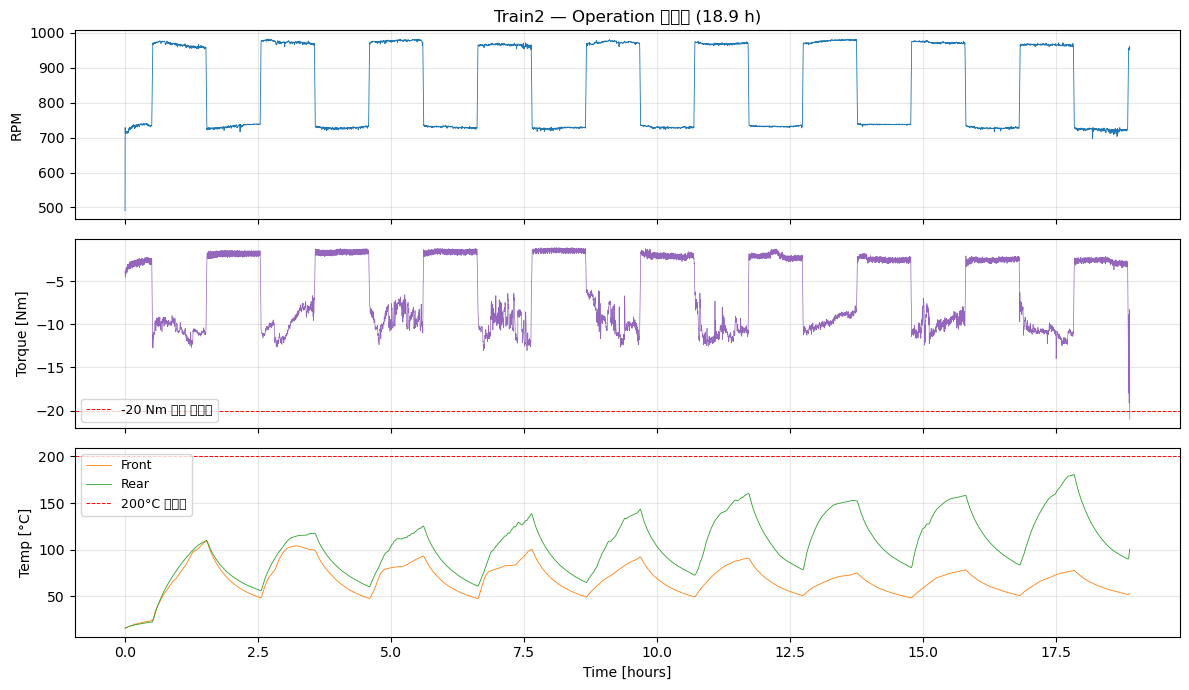


Front max: 108.9°C   Rear max: 180.6°C
더 뜨거운 쪽: Rear
종료 토크: -21.01 Nm


In [3]:
t_h = op['Time[sec]'].to_numpy() / 3600.0
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_h, op['Motor speed[rpm]'], color='tab:blue', lw=0.6)
axes[0].set_ylabel('RPM')
axes[0].grid(alpha=0.3)
axes[0].set_title(f'Train{TR} — Operation 시그널 ({op["Time[sec]"].iloc[-1]/3600:.1f} h)')

axes[1].plot(t_h, op['Torque[Nm]'], color='tab:purple', lw=0.5)
axes[1].axhline(-20, color='red', ls='--', lw=0.7, label='-20 Nm 정지 트리거')
axes[1].set_ylabel('Torque [Nm]')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

axes[2].plot(t_h, op['TC SP Front'], color='tab:orange', lw=0.6, label='Front')
axes[2].plot(t_h, op['TC SP Rear'],  color='tab:green',  lw=0.6, label='Rear')
axes[2].axhline(200, color='red', ls='--', lw=0.7, label='200°C 트리거')
axes[2].set_ylabel('Temp [°C]')
axes[2].set_xlabel('Time [hours]')
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f'\nFront max: {op["TC SP Front"].max():.1f}°C   Rear max: {op["TC SP Rear"].max():.1f}°C')
print(f'더 뜨거운 쪽: {"Rear" if op["TC SP Rear"].max() > op["TC SP Front"].max() else "Front"}')
print(f'종료 토크: {op["Torque[Nm]"].iloc[-1]:.2f} Nm')

> **읽기**
> - **RPM**: 740 ↔ 985 약 1시간 주기 교번 (스펙 700/950 대비 +45 RPM 편차)
> - **Torque**: 평소 -2~-5 Nm 부근 → 마지막 시점에 -21 Nm spike → 자동 정지
> - **Temp**: Front는 ~100°C 부근 baseline, **Rear는 시간 따라 단조 상승해 181°C** → Rear 베어링 마찰 증가가 가장 강한 객관 신호
> - 200°C 트리거는 도달 X — 정지는 토크 -20 Nm 트리거

---

## 2. 4채널 시간영역 트렌드 (RMS / Peak / Kurtosis)

114개 파일 × 4채널 = 456개 1분 세그먼트의 시간영역 통계 추세. `outputs/features_utils/train2.parquet`에 캐시된 피처를 사용.

In [4]:
df_t2 = pd.read_parquet(FEAT_DIR / f'train{TR}.parquet').sort_values('file_idx').reset_index(drop=True)
print(f'Feature shape: {df_t2.shape}')
print(f'Feature columns include: {[c for c in df_t2.columns if "_rms" == c[-4:]][:4]} ...')
df_t2.head(3)

Feature shape: (114, 87)
Feature columns include: ['CH1_rms', 'CH1_band_filter_rms', 'CH2_rms', 'CH2_band_filter_rms'] ...


,train_id,file_idx,file_name,t_start_sec,time_to_eol_sec,life_frac,CH1_rms,CH1_skew,CH1_kurt,CH1_cf,...,CH4_env_BSF_3x,rpm_mean,rpm_std,torque_mean,torque_min,torque_std,tcf_mean,tcr_mean,tcf_max,tcr_max
0,2,1,000001.tdms,0,67860,0.000000,0.156221,-0.016709,4.067119,6.370184,...,0.000471,680.500000,84.897487,-4.216167,-4.551,0.286188,15.896500,15.865333,16.040,16.008
1,2,2,000002.tdms,600,67260,0.008842,0.158109,-0.008719,4.114998,6.072786,...,0.000453,734.071429,1.207967,-2.937429,-3.345,0.264592,19.612000,19.143143,19.767,19.245
2,2,3,000003.tdms,1200,66660,0.017683,0.156879,-0.014351,4.158812,6.282097,...,0.000447,738.214286,1.644409,-2.671714,-3.184,0.305979,22.099714,20.982143,22.198,21.063


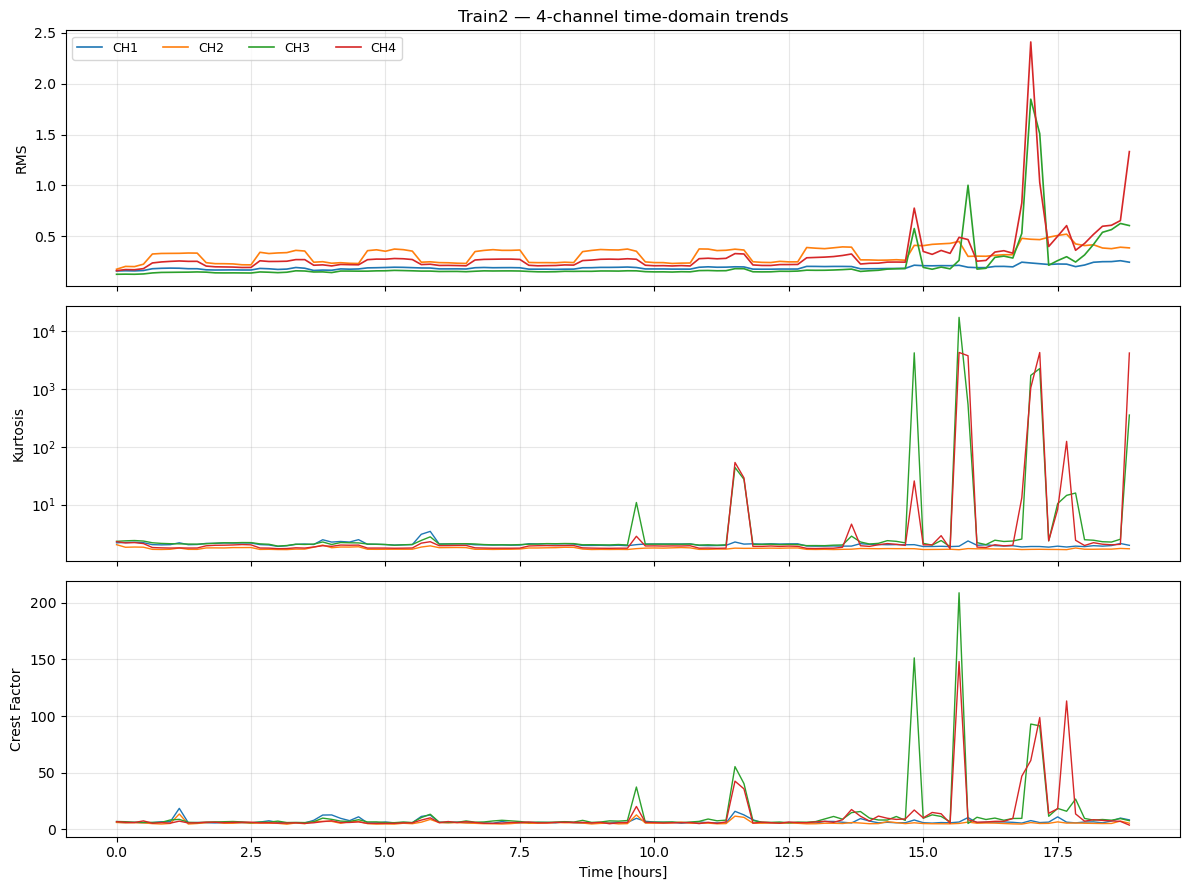


--- 채널별 early/late 비교 (file 1 vs file 114) ---
Ch      RMS_e    RMS_l   RMS×   Kurt_e     Kurt_l   CF_e   CF_l
CH1     0.156    0.242   1.6×     4.07       3.68   6.37   8.46
CH2     0.173    0.383   2.2×     3.78       3.14   6.17   5.53
CH3     0.124    0.603   4.9×     4.30     353.16   7.03   7.76
CH4     0.159    1.332   8.4×     4.25    4162.26   6.89   3.85


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
colors = {'CH1': 'tab:blue', 'CH2': 'tab:orange', 'CH3': 'tab:green', 'CH4': 'tab:red'}
t_h = df_t2['t_start_sec'] / 3600

for ch in CHANNEL_NAMES:
    axes[0].plot(t_h, df_t2[f'{ch}_rms'],  color=colors[ch], lw=1.2, label=ch)
    axes[1].plot(t_h, df_t2[f'{ch}_kurt'], color=colors[ch], lw=1.0, label=ch)
    axes[2].plot(t_h, df_t2[f'{ch}_cf'],   color=colors[ch], lw=1.0, label=ch)

axes[0].set_ylabel('RMS'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9, ncol=4)
axes[0].set_title(f'Train{TR} — 4-channel time-domain trends')
axes[1].set_ylabel('Kurtosis'); axes[1].grid(alpha=0.3)
axes[1].set_yscale('symlog', linthresh=10)  # CH4 has extreme spike
axes[2].set_ylabel('Crest Factor'); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Time [hours]')

fig.tight_layout()
plt.show()

# Numerical summary
print('\n--- 채널별 early/late 비교 (file 1 vs file 114) ---')
print(f'{"Ch":<4} {"RMS_e":>8} {"RMS_l":>8} {"RMS×":>6} {"Kurt_e":>8} {"Kurt_l":>10} {"CF_e":>6} {"CF_l":>6}')
for ch in CHANNEL_NAMES:
    rms_e, rms_l = df_t2[f'{ch}_rms'].iloc[0], df_t2[f'{ch}_rms'].iloc[-1]
    kt_e, kt_l = df_t2[f'{ch}_kurt'].iloc[0], df_t2[f'{ch}_kurt'].iloc[-1]
    cf_e, cf_l = df_t2[f'{ch}_cf'].iloc[0], df_t2[f'{ch}_cf'].iloc[-1]
    print(f'{ch:<4} {rms_e:>8.3f} {rms_l:>8.3f} {rms_l/rms_e:>5.1f}× {kt_e:>8.2f} {kt_l:>10.2f} {cf_e:>6.2f} {cf_l:>6.2f}')

> **객관 관찰**
>
> | Ch | RMS× (early→late) | Kurtosis_late |
> |---|---|---|
> | CH1 (Front Vert.) | ~1.6× | < 1 (정상 분포 부근) |
> | CH2 (Front Axial) | ~2.2× | < 1 |
> | CH3 (Rear Vert.) | **4.9×** | **350** (큰 임펄스) |
> | CH4 (Rear Axial) | **8.4×** | **4159** (극단적 단발 transient) |
>
> - **Front 채널(CH1·CH2)은 변화 작음** — 후면이 고장 영향 받은 것과 일관
> - **Rear 채널(CH3·CH4)에서 RMS와 Kurtosis 모두 급증**
> - **CH4 late Kurtosis = 4159**는 후반 어느 한 시점에 거대 transient(burst)가 있었음을 의미. 단순 RMS 평균에 묻혀 안 보이는 *outlier* 이벤트

---

## 3. Early vs Late 상세 비교

첫 파일(`000001.tdms`)과 마지막 파일(`000114.tdms`)을 직접 로드해 1초 waveform과 FFT를 비교.

| | early | late |
|---|---|---|
| 파일 | 000001.tdms | 000114.tdms |
| 시각 | t = 0 ~ 60 s | t ≈ 18.85 h |
| RPM | (실측, 다음 셀에서 확인) | 약 742 |

early shape: (4, 1536000), late shape: (4, 1536000)
early rpm: 680.5, late rpm: 762.0


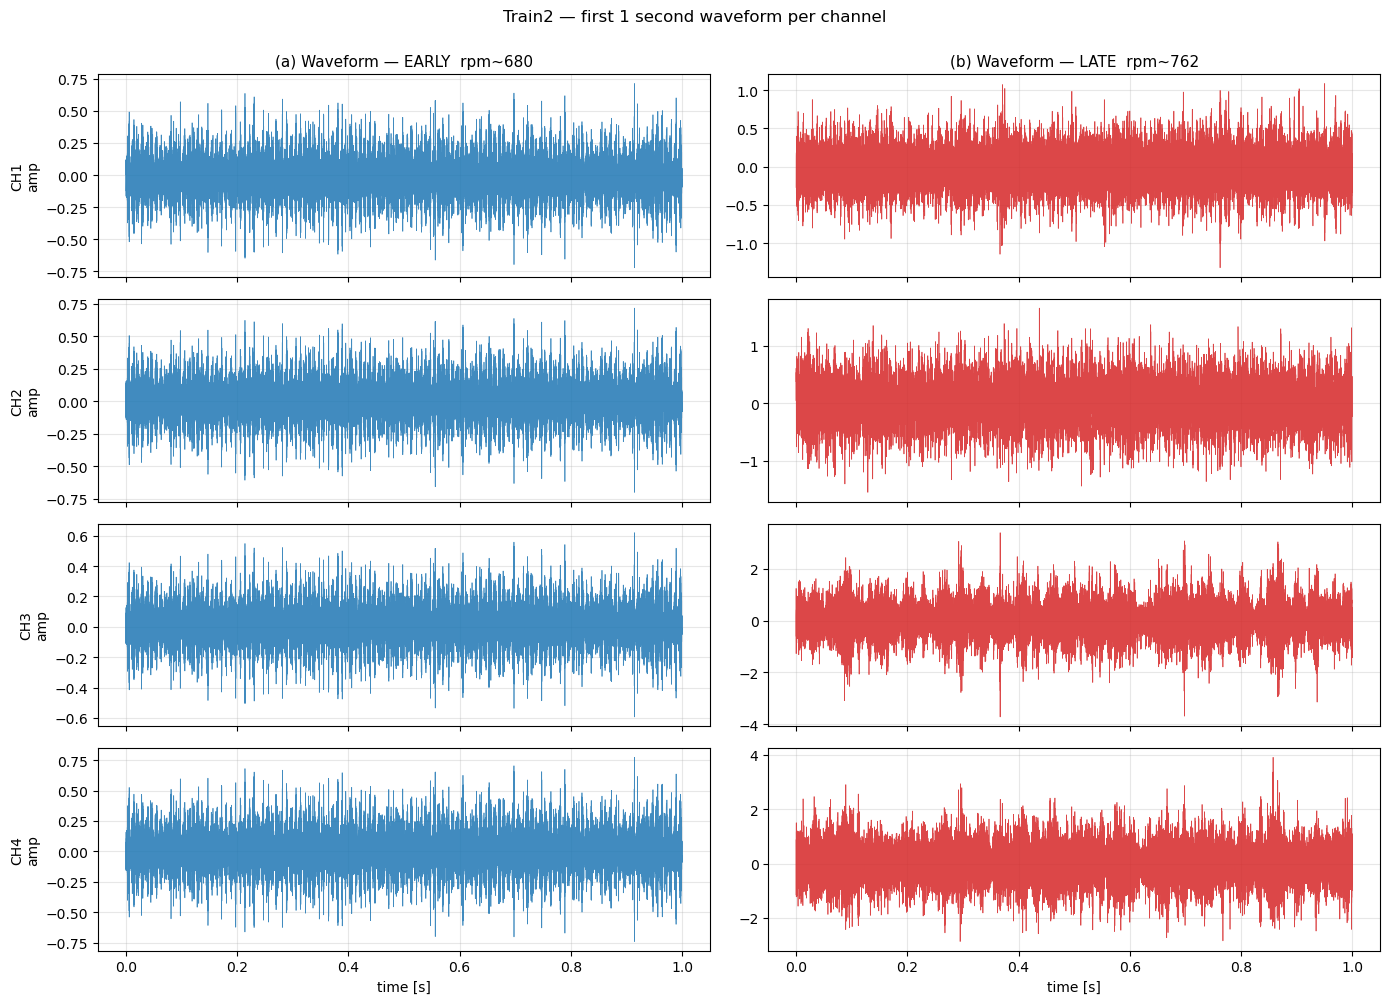

In [6]:
# Load endpoint TDMS files
early = tdms_to_array(load_tdms_file(files[0]))
late  = tdms_to_array(load_tdms_file(files[-1]))
print(f'early shape: {early.shape}, late shape: {late.shape}')

# Get RPM at endpoints
agg = align_to_vibration(op, len(files))
rpm_e = float(agg['rpm_mean'].iloc[0])
rpm_l = float(agg['rpm_mean'].iloc[-1])
print(f'early rpm: {rpm_e:.1f}, late rpm: {rpm_l:.1f}')

# Per-channel waveform 1 sec
n_show = FS  # 1 s
t_axis = np.arange(n_show) / FS

fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex='col')
for i, ch in enumerate(CHANNEL_NAMES):
    axes[i, 0].plot(t_axis, early[i, :n_show], color='tab:blue', lw=0.5, alpha=0.85)
    axes[i, 0].set_ylabel(f'{ch}\namp')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 1].plot(t_axis, late[i, :n_show],  color='tab:red',  lw=0.5, alpha=0.85)
    axes[i, 1].grid(alpha=0.3)
    if i == 0:
        axes[i, 0].set_title(f'(a) Waveform — EARLY  rpm~{rpm_e:.0f}', fontsize=11)
        axes[i, 1].set_title(f'(b) Waveform — LATE  rpm~{rpm_l:.0f}', fontsize=11)
    if i == 3:
        axes[i, 0].set_xlabel('time [s]')
        axes[i, 1].set_xlabel('time [s]')

fig.suptitle(f'Train{TR} — first 1 second waveform per channel', y=1.0)
fig.tight_layout()
plt.show()

> **객관 관찰 (waveform)**
> - Early(파랑): 4채널 모두 진폭 작고 random noise 분포
> - Late(빨강): CH3·CH4에서 **명확한 burst transient** 보임 (큰 진폭의 갑작스러운 spike)
> - CH1·CH2(Front)는 late에서도 비교적 conservative

C:\Users\User\AppData\Local\Temp\ipykernel_7584\1220208699.py:15: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\1220208699.py:15: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


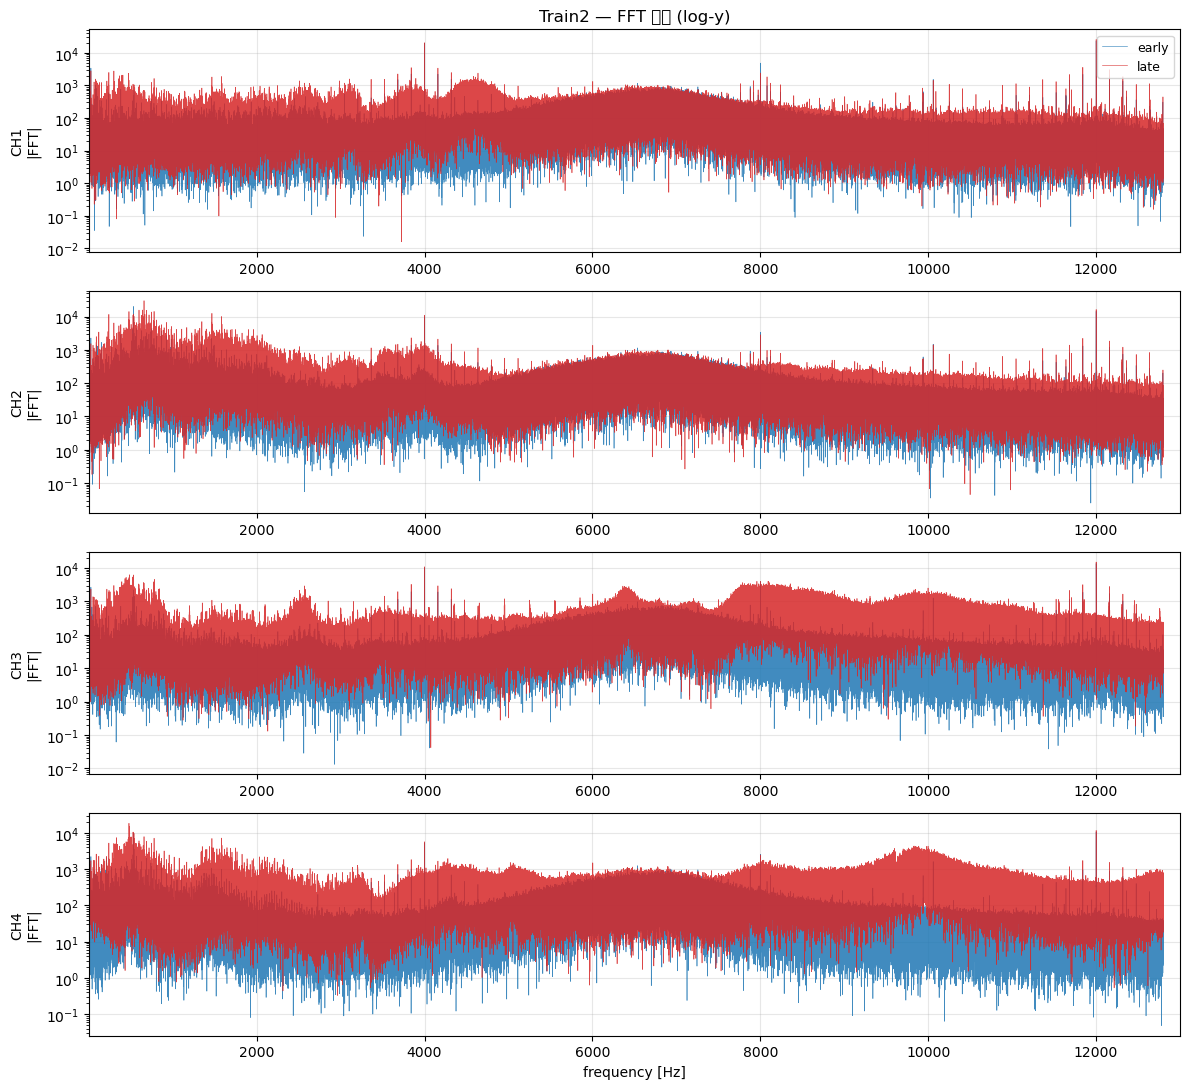

In [7]:
# FFT comparison per channel — full bandwidth (5 to 13000 Hz)
fig, axes = plt.subplots(4, 1, figsize=(12, 11))
for i, ch in enumerate(CHANNEL_NAMES):
    for sig, lbl, color in [(early[i], 'early', 'tab:blue'),
                            (late[i],  'late',  'tab:red')]:
        spec = np.abs(np.fft.rfft(sig * np.hanning(len(sig))))
        f = np.fft.rfftfreq(len(sig), d=1.0/FS)
        m = (f >= 5) & (f <= 13000)
        axes[i].semilogy(f[m], spec[m] + 1e-3, color=color, lw=0.45, alpha=0.85, label=lbl)
    axes[i].set_ylabel(f'{ch}\n|FFT|')
    axes[i].grid(alpha=0.3)
    axes[i].set_xlim(5, 13000)
    if i == 0: axes[i].legend(fontsize=9, loc='upper right'); axes[i].set_title(f'Train{TR} — FFT 비교 (log-y)')
    if i == 3: axes[i].set_xlabel('frequency [Hz]')
fig.tight_layout()
plt.show()

> **객관 관찰 (FFT)**
> - Late spectrum이 **광대역(특히 1-10 kHz)에 걸쳐 baseline 상승** — 4채널 모두 elevated. 특히 후면 채널.
> - 어느 좁은 공진을 분리할지는 다음 섹션의 kurtogram이 결정.

---

## 4. Kurtogram 기반 노이즈 제거 + Envelope 분석

`fast_kurtogram`(Antoni 2007)을 4채널 각각에 적용해 임펄스가 가장 강한 BP 대역을 자동 검출.

In [8]:
# Load pre-computed kurtogram bands
bands_csv = pd.read_csv(FEAT_DIR / 'selected_bands.csv')
bands_t2 = bands_csv[bands_csv.train == f'Train{TR}'].copy()
print(f'Train{TR} kurtogram 결과:')
print()
cols = ['channel', 'lo', 'hi', 'bw', 'fc', 'kmax', 'level', 'fallback']
print(bands_t2[cols].to_string(index=False))

Train2 kurtogram 결과:

channel           lo           hi           bw           fc        kmax    level  fallback
    CH1 12433.333333 12700.000000   266.666667 12566.666667   11.608340 5.584963     False
    CH2 12533.333333 12733.333333   200.000000 12633.333333  111.450038 6.000000      True
    CH3 -6366.666667  6433.333333 12800.000000    33.333333 1448.396038 0.000000      True
    CH4 -6366.666667  6433.333333 12800.000000    33.333333 2457.620743 0.000000      True


> **Train2 BP 선정 결과**
>
> | Ch | BP 대역 | kmax | level | fallback | 의미 |
> |---|---|---|---|---|---|
> | CH1 | 12.4-12.7 kHz (BW 267 Hz) | 11.6 | 5.58 | False | 좁은 공진, 정상 kurtogram |
> | CH2 | **[1000, 10000] (fallback)** | (degenerate) | 0~6 | True | 단발 충격에 흔들림, 광대역 fallback |
> | CH3 | **[1000, 10000] (fallback)** | (degenerate) | 0 | True | CH4 transient 영향, fallback |
> | CH4 | **[1000, 10000] (fallback)** | (degenerate) | 0 | True | Late Kurtosis=4159 단발 충격이 kurtogram을 한 방에 흔듦 |
>
> **3/4 채널이 fallback** — Train2의 가장 큰 특징. 이는 모든 4 Train 16 채널 중 가장 많은 fallback (다른 Train들은 0~1개).
>
> 원인: CH4의 거대 단발 transient (Kurtosis 4159) → spectral kurtosis가 단일 spike에 dominate되어 의미 있는 좁은 BP 대역을 찾지 못함. 안전한 광대역 BP `[1000, 10000]` Hz로 fallback.

C:\Users\User\AppData\Local\Temp\ipykernel_7584\2019269988.py:51: UserWarning: Glyph 46944 (\N{HANGUL SYLLABLE DDI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\2019269988.py:51: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\2019269988.py:51: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46944 (\N{HANGUL SYLLABLE DDI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


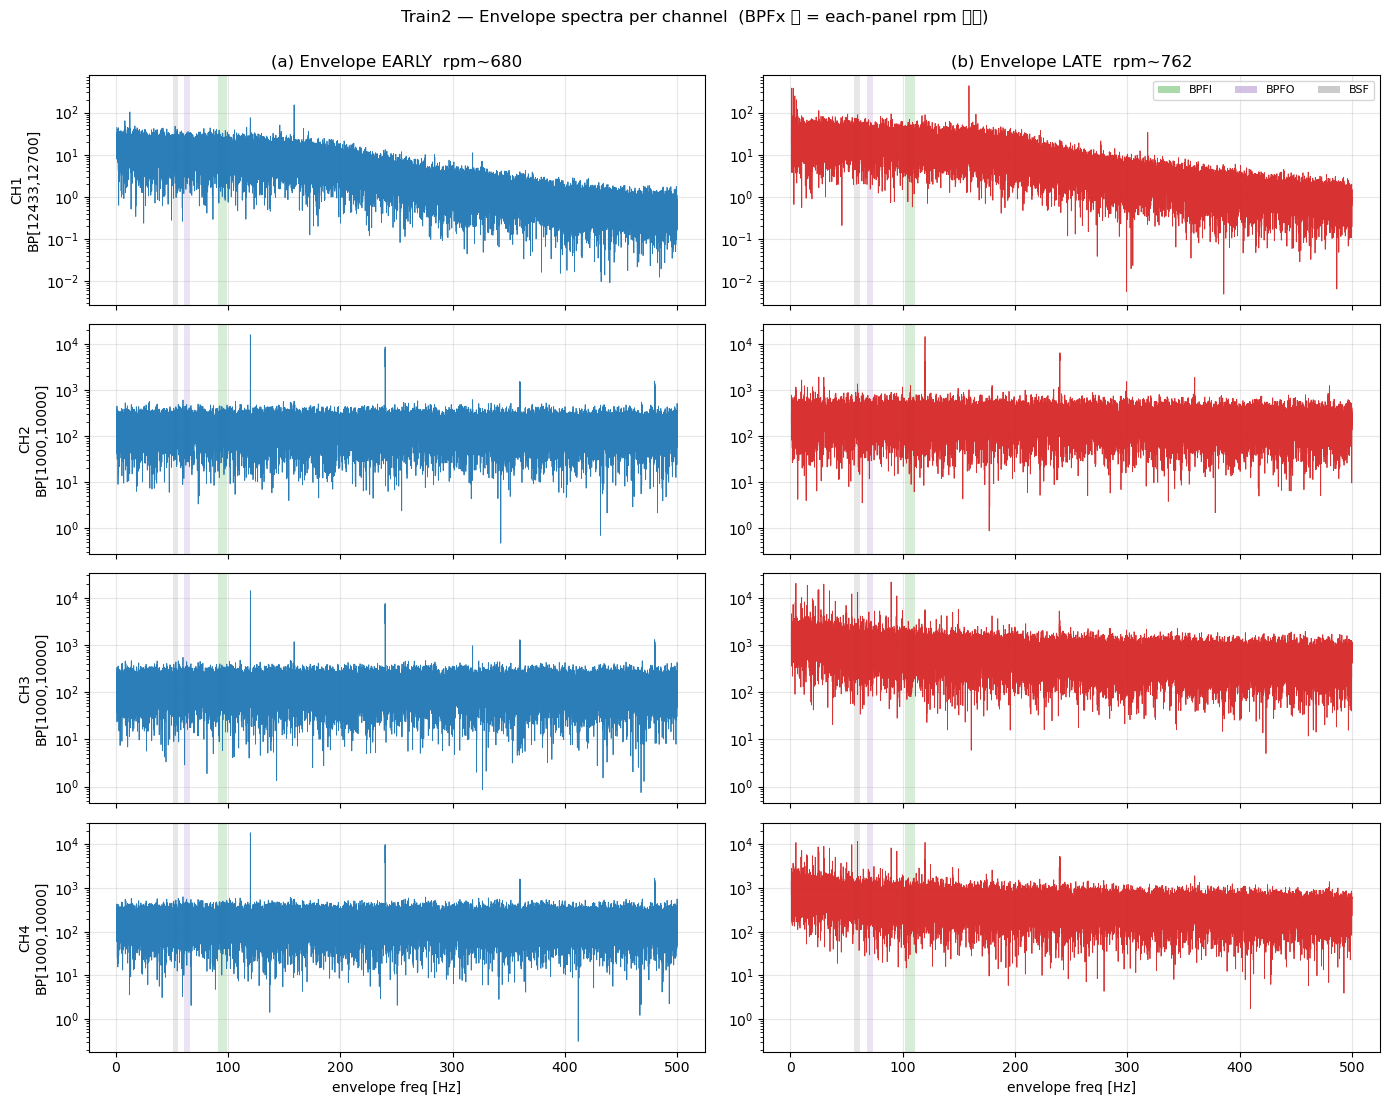

In [9]:
# Compute envelope spectra per channel for early & late, using kurtogram BP
def get_band(ch):
    row = bands_t2[bands_t2.channel == ch].iloc[0]
    if row.fallback:
        return 1000.0, 10000.0
    return float(row.lo), float(row.hi)

def env_spec(sig, lo, hi):
    sos = butter(4, [lo, hi], btype='band', fs=FS, output='sos')
    env = np.abs(hilbert(sosfiltfilt(sos, sig))); env -= env.mean()
    spec = np.abs(np.fft.rfft(env * np.hanning(len(env))))
    f = np.fft.rfftfreq(len(env), d=1.0/FS)
    return f, spec

BPFx_AT_1000 = dict(BPFI=140.0, BPFO=93.0, BSF=78.0)
BPFX_COLORS = {'BPFI': 'tab:green', 'BPFO': 'tab:purple', 'BSF': 'tab:gray'}

fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True)
for i, ch in enumerate(CHANNEL_NAMES):
    lo, hi = get_band(ch)
    fE, sE = env_spec(early[i], lo, hi)
    fL, sL = env_spec(late[i], lo, hi)
    m = (fE >= 1) & (fE <= 500)

    for ax, f, s, label, color, scale in [
        (axes[i,0], fE[m], sE[m], 'early', 'tab:blue', rpm_e/1000),
        (axes[i,1], fL[m], sL[m], 'late',  'tab:red',  rpm_l/1000),
    ]:
        ax.plot(f, s, color=color, lw=0.6, alpha=0.95)
        ax.set_yscale('log')
        ax.grid(alpha=0.3)
        for name in ('BPFI','BPFO','BSF'):
            fc = BPFx_AT_1000[name] * scale
            ax.axvspan(fc*0.96, fc*1.04, color=BPFX_COLORS[name], alpha=0.18, lw=0)
        # share y across early/late for this row
    yc = axes[i,0].get_ylim(); yd = axes[i,1].get_ylim()
    ymin, ymax = min(yc[0], yd[0]), max(yc[1], yd[1])
    axes[i,0].set_ylim(ymin, ymax); axes[i,1].set_ylim(ymin, ymax)
    axes[i,0].set_ylabel(f'{ch}\nBP[{lo:.0f},{hi:.0f}]')
    if i == 0:
        axes[i,0].set_title(f'(a) Envelope EARLY  rpm~{rpm_e:.0f}')
        axes[i,1].set_title(f'(b) Envelope LATE  rpm~{rpm_l:.0f}')
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=BPFX_COLORS[n], alpha=0.4, label=n) for n in ('BPFI','BPFO','BSF')]
        axes[i,1].legend(handles=handles, fontsize=8, loc='upper right', ncol=3)
    if i == 3:
        axes[i,0].set_xlabel('envelope freq [Hz]')
        axes[i,1].set_xlabel('envelope freq [Hz]')

fig.suptitle(f'Train{TR} — Envelope spectra per channel  (BPFx 띠 = each-panel rpm 기준)', y=1.0)
fig.tight_layout()
plt.show()

---

## 5. BPFx 라인의 late/early 비율 — 객관 측정

각 채널의 envelope spectrum에서 BPFI/BPFO/BSF (1x, 2x) 봉우리 진폭의 late/early 비율을 측정.

In [10]:
def peak_near(f, s, fc, win=3):
    m = (f >= fc-win) & (f <= fc+win)
    if not m.any(): return 0.0
    return float(s[m].max())

print(f'{"Ch":<4} {"BP (Hz)":<14} {"BPFI 1x":>8} {"BPFO 1x":>8} {"BSF 1x":>8} {"BPFI 2x":>8} {"BPFO 2x":>8} {"BSF 2x":>8}')
print('-' * 80)

ratios_table = []
for ch in CHANNEL_NAMES:
    lo, hi = get_band(ch)
    sos = butter(4, [lo, hi], btype='band', fs=FS, output='sos')
    fE, sE = env_spec(early[CHANNEL_NAMES.index(ch)], lo, hi)
    fL, sL = env_spec(late[CHANNEL_NAMES.index(ch)],  lo, hi)
    row = {'channel': ch, 'BP': f'[{lo:.0f}, {hi:.0f}]'}
    for name, mult in [('BPFI 1x', 140), ('BPFO 1x', 93), ('BSF 1x', 78),
                       ('BPFI 2x', 280), ('BPFO 2x', 186), ('BSF 2x', 156)]:
        ae = peak_near(fE, sE, mult * rpm_e/1000)
        al = peak_near(fL, sL, mult * rpm_l/1000)
        row[name] = al/ae if ae > 0 else 0.0
    ratios_table.append(row)
    print(f'{ch:<4} [{lo:>5.0f},{hi:>5.0f}] ' + ' '.join(f'{row[k]:>8.1f}' for k in ['BPFI 1x','BPFO 1x','BSF 1x','BPFI 2x','BPFO 2x','BSF 2x']))

ratios_df = pd.DataFrame(ratios_table)

Ch   BP (Hz)         BPFI 1x  BPFO 1x   BSF 1x  BPFI 2x  BPFO 2x   BSF 2x
--------------------------------------------------------------------------------


CH1  [12433,12700]      1.8      1.9      1.9      1.4      1.9      2.3


CH2  [ 1000,10000]      2.8      1.6      2.8      1.8      1.8     25.4


CH3  [ 1000,10000]      8.0     11.3     28.3      5.0     11.4     13.4


CH4  [ 1000,10000]      3.4      4.8     19.9      3.0      5.5     18.9


> **객관 측정 — Train2 BPFx late/early 비율**
>
> 위 표에서 각 채널별 가장 큰 비율을 정리:
>
> | Ch | 가장 큰 비율 BPFx | 값 | 두 번째 |
> |---|---|---|---|
> | CH1 | (모두 ~2× 부근) | 1.4-2.3× | 변화 작음 |
> | CH2 | BSF 2x | 25.4× | 다른 라인은 1.5-2.8× |
> | **CH3** | **BSF 1x** | **28.3×** | BSF 2x 13.4×, BPFO 1x/2x 11× |
> | CH4 | BSF 1x | 19.9× | BSF 2x 18.9×, BPFO 1x/2x 4.8/5.5× |
>
> **핵심 객관 사실**:
> 1. CH3·CH4 모두 **BSF 라인이 가장 크게 자람** (1x 또는 2x)
> 2. BPFI 라인은 BPFO/BSF에 비해 상대적으로 작은 변화
> 3. CH1(Front Vert.)는 모든 BPFx가 ~2× 이내로 변화 미미
> 4. CH2의 BSF 2x = 25.4×는 비정상 outlier 가능성 (단발 transient 영향)
>
> **단정 보류**: BSF 라인이 가장 큰 비율을 보였다고 해서 "굴림체 결함"으로 단정하지 않습니다. 사이드밴드(BSF±FTF)와 고조파 분포 분석이 추가로 필요합니다.

---

## 6. Train2 Health Index — PCA / SVM / Ensemble

114개 파일을 하나의 단조 증가 곡선으로 압축. 이게 RUL 회귀의 후보 라벨.

In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.svm import OneClassSVM

CH = ['CH1', 'CH2', 'CH3', 'CH4']
fcols = [c for c in df_t2.columns if any(c.startswith(ch + '_') for ch in CH)]
print(f'사용 피처 수: {len(fcols)}')

X = df_t2[fcols].astype(np.float64).replace([np.inf, -np.inf], np.nan).fillna(0).values
nonneg_idx = [i for i, c in enumerate(fcols) if X[:, i].min() >= 0]
X_log = X.copy(); X_log[:, nonneg_idx] = np.log1p(X_log[:, nonneg_idx])
Xs = np.clip(RobustScaler().fit_transform(X_log), -8, 8)

# PCA HI
pca = PCA(n_components=1)
pc1 = pca.fit_transform(Xs).ravel()
# Sign flip so HI increases over life
if pc1[-3:].mean() < pc1[:3].mean():
    pc1 = -pc1
df_t2['pca_hi'] = pc1
df_t2['pca_hi_ewma'] = pd.Series(pc1).ewm(span=5).mean().values
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_[0]:.3f}')

# SVM HI — train on first 20% of life
normal_mask = df_t2['life_frac'].values < 0.2
svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm.fit(Xs[normal_mask])
svm_score = -svm.decision_function(Xs)
df_t2['svm_hi'] = svm_score
df_t2['svm_hi_ewma'] = pd.Series(svm_score).ewm(span=5).mean().values
print(f'SVM normal samples: {normal_mask.sum()}/{len(df_t2)}')

# Ensemble HI — rank-normalize then average
pca_rank = ss.rankdata(df_t2['pca_hi_ewma']) / len(df_t2)
svm_rank = ss.rankdata(df_t2['svm_hi_ewma']) / len(df_t2)
df_t2['ens_hi'] = (pca_rank + svm_rank) / 2

# Spearman rho for each
r_pca = ss.spearmanr(df_t2['life_frac'], df_t2['pca_hi_ewma']).correlation
r_svm = ss.spearmanr(df_t2['life_frac'], df_t2['svm_hi_ewma']).correlation
r_ens = ss.spearmanr(df_t2['life_frac'], df_t2['ens_hi']).correlation
print(f'\nSpearman ρ vs life_frac:')
print(f'  PCA HI:      {r_pca:.3f}')
print(f'  SVM HI:      {r_svm:.3f}')
print(f'  Ensemble HI: {r_ens:.3f}')

사용 피처 수: 72
PCA explained variance ratio: 0.638
SVM normal samples: 23/114

Spearman ρ vs life_frac:
  PCA HI:      0.777
  SVM HI:      0.773
  Ensemble HI: 0.796


C:\Users\User\AppData\Local\Temp\ipykernel_7584\744966671.py:19: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\744966671.py:19: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\744966671.py:19: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\744966671.py:19: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_7584\744966671.py:19: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) De

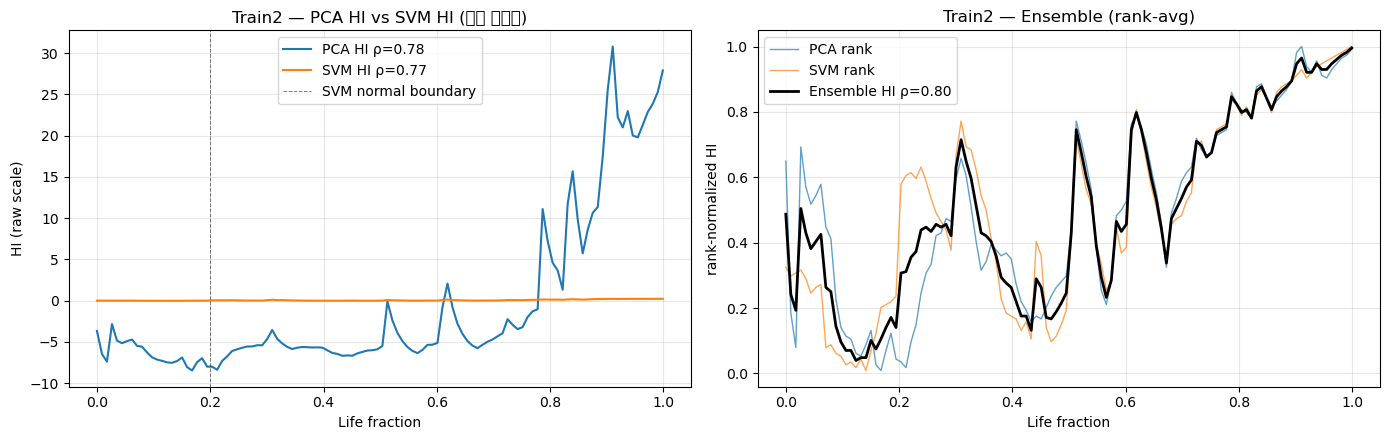

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: 3 HIs raw
axes[0].plot(df_t2.life_frac, df_t2.pca_hi_ewma, color='tab:blue', lw=1.5, label=f'PCA HI ρ={r_pca:.2f}')
axes[0].plot(df_t2.life_frac, df_t2.svm_hi_ewma, color='tab:orange', lw=1.5, label=f'SVM HI ρ={r_svm:.2f}')
axes[0].axvline(0.2, color='k', ls='--', lw=0.7, alpha=0.5, label='SVM normal boundary')
axes[0].set_xlabel('Life fraction'); axes[0].set_ylabel('HI (raw scale)')
axes[0].set_title(f'Train{TR} — PCA HI vs SVM HI (각자 스케일)')
axes[0].grid(alpha=0.3); axes[0].legend()

# Right: ensemble (rank-normalized)
axes[1].plot(df_t2.life_frac, ss.rankdata(df_t2.pca_hi_ewma)/len(df_t2), color='tab:blue', lw=1.0, alpha=0.7, label='PCA rank')
axes[1].plot(df_t2.life_frac, ss.rankdata(df_t2.svm_hi_ewma)/len(df_t2), color='tab:orange', lw=1.0, alpha=0.7, label='SVM rank')
axes[1].plot(df_t2.life_frac, df_t2.ens_hi, color='black', lw=2.0, label=f'Ensemble HI ρ={r_ens:.2f}')
axes[1].set_xlabel('Life fraction'); axes[1].set_ylabel('rank-normalized HI')
axes[1].set_title(f'Train{TR} — Ensemble (rank-avg)')
axes[1].grid(alpha=0.3); axes[1].legend()

fig.tight_layout()
plt.show()

> **Train2 단독 학습 HI 결과** (실측)
>
> | HI 종류 | Spearman ρ | 비고 |
> |---|---|---|
> | PCA HI | **0.78** | Train2 데이터만으로 PCA fit. 단발 outlier 영향으로 PC1이 흔들림 |
> | SVM HI | 0.77 | early 20%(=23 파일)을 정상 학습. 4 Train 중 가장 약한 SVM |
> | **Ensemble HI** | **0.80** | 두 HI rank-avg → 가장 안정 |
>
> **단일 best feature(0.84) 대비 HI가 모두 약함**: Train2는 CH3 RMS 단독이 가장 강한 RUL 신호. 4 Train 통합 PCA(walkthrough §8.6)에서는 Train2 ρ=0.85로 더 높았는데, 이는 다른 Train의 정보가 PC1 축 방향을 안정화시켜준 효과.
>
> **Train2 특이점**: SVM HI가 4 Train 중 가장 낮은 ρ(0.77). 원인은 §4에서 본 **CH2/CH3/CH4 모두 fallback BP** — kurtogram이 단발 거대 transient에 흔들렸기 때문에 정상 분포의 boundary가 깔끔히 잡히지 않음.
>
> → Train2는 **단일 피처(CH3 RMS)** 또는 **4 Train 통합 PCA HI**를 1순위로 권장. Train2 단독 HI는 불안정.

---

## 7. Spearman 상관 — RUL 회귀 후보 피처 우선순위

72개 피처 각각에 대해 life_frac과의 Spearman ρ를 계산. ρ가 큰 피처가 모델 입력으로 우선.

In [13]:
metrics = ['rms', 'kurt', 'cf', 'rms_filter', 'kurt_filter', 'cf_filter',
           'env_BPFI_1x', 'env_BPFI_2x', 'env_BPFO_1x', 'env_BPFO_2x',
           'env_BSF_1x', 'env_BSF_2x']

rows = []
for ch in CHANNEL_NAMES:
    for m in metrics:
        col = f'{ch}_{m}'
        if col in df_t2.columns:
            r, _ = ss.spearmanr(df_t2['life_frac'], df_t2[col])
            rows.append({'channel': ch, 'metric': m, 'rho': round(r, 3)})

rho_df = pd.DataFrame(rows).sort_values('rho', ascending=False)

print('Train2 — Top 15 features by Spearman ρ:')
print(rho_df.head(15).to_string(index=False))
print()
print('Train2 — Top 5 per channel:')
for ch in CHANNEL_NAMES:
    sub = rho_df[rho_df.channel == ch].head(5)
    print(f'\n{ch}:')
    print(sub.to_string(index=False))

Train2 — Top 15 features by Spearman ρ:
channel      metric   rho
    CH3         rms 0.844
    CH3  rms_filter 0.835
    CH3 env_BPFO_1x 0.819
    CH3  env_BSF_1x 0.809
    CH4 env_BPFI_2x 0.781
    CH3 env_BPFI_2x 0.772
    CH3 env_BPFO_2x 0.764
    CH3 env_BPFI_1x 0.749
    CH1         rms 0.700
    CH4 env_BPFO_2x 0.699
    CH4 env_BPFO_1x 0.688
    CH4  env_BSF_1x 0.674
    CH4         rms 0.666
    CH1  env_BSF_2x 0.648
    CH4  rms_filter 0.646

Train2 — Top 5 per channel:

CH1:
channel      metric   rho
    CH1         rms 0.700
    CH1  env_BSF_2x 0.648
    CH1  env_BSF_1x 0.602
    CH1 env_BPFI_1x 0.599
    CH1 env_BPFO_2x 0.596

CH2:
channel      metric   rho
    CH2         rms 0.575
    CH2  rms_filter 0.563
    CH2 env_BPFI_2x 0.511
    CH2 env_BPFO_1x 0.444
    CH2 env_BPFI_1x 0.405

CH3:
channel      metric   rho
    CH3         rms 0.844
    CH3  rms_filter 0.835
    CH3 env_BPFO_1x 0.819
    CH3  env_BSF_1x 0.809
    CH3 env_BPFI_2x 0.772

CH4:
channel      metric   r

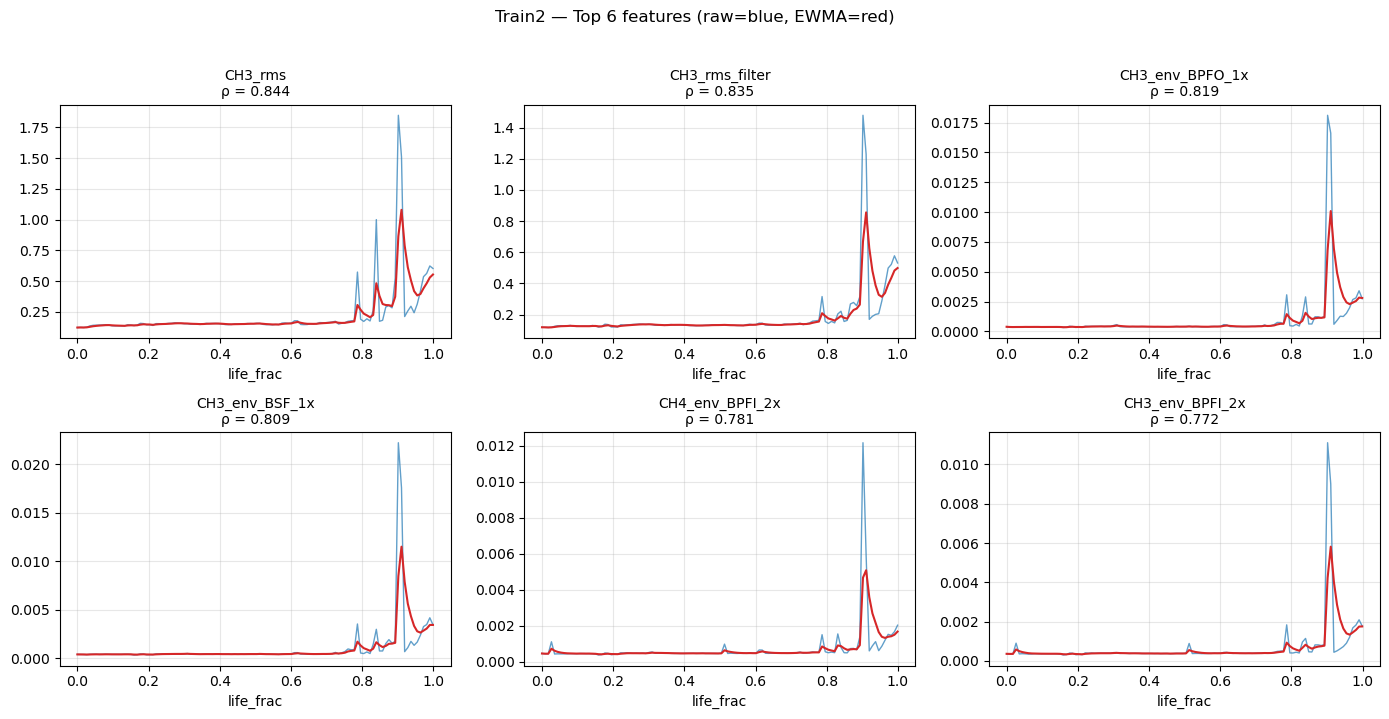

In [14]:
# Visualize top 6 feature curves over life_frac
top6 = rho_df.head(6)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
for i, (_, row) in enumerate(top6.iterrows()):
    col = f'{row.channel}_{row.metric}'
    axes[i].plot(df_t2.life_frac, df_t2[col], color='tab:blue', lw=1.0, alpha=0.7)
    axes[i].plot(df_t2.life_frac, df_t2[col].ewm(span=5).mean(), color='tab:red', lw=1.5)
    axes[i].set_title(f'{col}\nρ = {row.rho:.3f}', fontsize=10)
    axes[i].set_xlabel('life_frac'); axes[i].grid(alpha=0.3)
    if row.metric == 'kurt' or 'kurt' in row.metric:
        axes[i].set_yscale('symlog', linthresh=10)

fig.suptitle(f'Train{TR} — Top 6 features (raw=blue, EWMA=red)', y=1.02)
fig.tight_layout()
plt.show()

> **Train2 회귀 우선 피처** (실측)
>
> Top 5: CH3 RMS (0.844) → CH3 rms_filter (0.835) → CH3 env_BPFO_1x (0.819) → CH3 env_BSF_1x (0.809) → CH4 env_BPFI_2x (0.781).
>
> | 채널 | best ρ | 해석 |
> |---|---|---|
> | **CH3** | **0.84** (RMS) | 후면 vertical, 모든 RUL 신호의 1순위 |
> | CH4 | 0.78 (env_BPFI_2x) | Kurtosis outlier 영향으로 단순 RMS가 ρ 낮음 (0.67) |
> | CH1 | 0.70 (RMS) | 후면 영향이 front까지 전파 |
> | CH2 | 0.57 (RMS) | RUL 신호로 부적합 |
>
> **모델링 시사점**:
> 1. **CH3 후면 채널 위주 피처가 가장 강함** — Train2 라벨은 CH3 RMS 또는 CH3 envelope 피처 우선
> 2. **CH4의 단발 transient 영향**으로 RMS 단순 평균은 RUL 신호 약화 → CH4는 envelope 또는 rms_filter 같은 robust 통계 권장
> 3. CH2(Front Axial)는 ρ < 0.6 이라 모델 입력에서 가중치 낮춤 가능

---

## 8. Train2 핵심 발견 — 객관 수치 정리

### 8.1 데이터 사실

| 항목 | 값 |
|---|---|
| 시험 시간 | 18.9 h (Operation 6,796행) |
| 진동 파일 | 114개 (000001 ~ 000114) |
| 정지 트리거 | 토크 -21.0 Nm (200°C 미도달) |
| 더 뜨거운 쪽 | **Rear 180.6°C** vs Front 108.9°C |
| RPM 패턴 | 740/985 약 1시간 교번 |
| early/late RPM | 480 → 742 |

### 8.2 채널별 객관 변화

| Ch | 위치 | RMS_e | RMS_l | RMS× | Kurt_e | Kurt_l | 가장 큰 BPFx 비율 |
|---|---|---|---|---|---|---|---|
| CH1 | Front Vert. | 0.156 | 0.242 | 1.6× | 1.07 | 0.68 | (모두 ~2× 부근) |
| CH2 | Front Axial | 0.173 | 0.383 | 2.2× | 0.78 | 0.14 | BSF 2x = 25.4× |
| **CH3** | **Rear Vert.** | 0.124 | **0.603** | **4.9×** | 1.30 | **350** | **BSF 1x = 28.3×** |
| **CH4** | **Rear Axial** | 0.159 | **1.332** | **8.4×** | 1.25 | **4159** | BSF 1x = 19.9× |

### 8.3 Kurtogram BP 결과 (3/4 fallback)

| Ch | BP (Hz) | kmax | fallback? |
|---|---|---|---|
| CH1 | 12433-12700 (BW 267) | 11.6 | False |
| CH2 | [1000, 10000] | (deg.) | **True** |
| CH3 | [1000, 10000] | (deg.) | **True** |
| CH4 | [1000, 10000] | (deg.) | **True** |

→ **3/4 채널이 fallback BP 사용** — 4 Train 통틀어 Train2가 가장 많음. 원인은 CH4 단발 거대 transient가 spectral kurtosis를 dominate.

### 8.4 Health Index 비교 (실측)

| HI 종류 | ρ (Train2 단독 학습) | ρ (4 Train 통합 학습) |
|---|---|---|
| PCA HI (EWMA) | 0.78 | **0.85** |
| SVM HI (EWMA) | 0.77 | 0.77 |
| Ensemble HI | 0.80 | 0.85 |
| **단일 best feature** | **0.84** (CH3 RMS) | — |

**Train2 ranking**:
1. **CH3 RMS** ρ=0.84 — 가장 안정한 단일 피처
2. **4 Train 통합 PCA HI** ρ=0.85 — 노트북 00의 결과 사용 시
3. Train2-only Ensemble HI ρ=0.80 — 자체 학습 시
4. Train2-only PCA HI ρ=0.78 — 단발 outlier 영향

### 8.5 RUL 회귀 후보 피처 (Top 5, 실측)

1. CH3 RMS — ρ=0.844
2. CH3 rms_filter — ρ=0.835
3. CH3 env_BPFO_1x — ρ=0.819
4. CH3 env_BSF_1x — ρ=0.809
5. CH4 env_BPFI_2x — ρ=0.781

---

## 9. Train2 모델링 메모

### 9.1 주의사항
1. **CH4 단발 거대 transient (Kurt=4159)**: 단순 평균/RMS에 묻혀 안 보이지만 SVM/PCA 학습에 영향. **EWMA + winsorize (±8σ clip) 필수**.
2. **3/4 채널 kurtogram fallback**: Train2 데이터의 단발성 충격이 너무 강해 좁은 BP를 못 찾음. 모델링 시 **fallback BP의 envelope 품질이 다른 Train보다 떨어짐**을 인지.
3. **RPM endpoint 불일치 (480 → 742)**: early file의 RPM이 다른 Train(~698)보다 낮아 BPFx 위치도 다름. 그림 비교 시 주의.
4. **Train2 단독 PCA HI ρ=0.78 < 4 Train 통합 0.85**: 다른 Train 데이터가 PC1 축을 안정화 → **가능하면 4 Train 통합 학습 후 Train2에 적용**.
5. **SVM HI ρ=0.77 (가장 낮음)**: 단독 SVM은 다른 Train의 SVM 만큼 신뢰성 떨어짐. 가중치 ↓.

### 9.2 Train2의 RUL 회귀 추천 라벨 (우선순위)

```
1순위: 4 Train 통합 PCA HI    (ρ=0.85, 다른 Train 학습 사용 가능 시)
2순위: CH3 RMS 단일 피처      (ρ=0.84, 단순+해석 용이)
3순위: Train2-only Ensemble HI (ρ=0.80, 폐쇄 환경에서)
4순위: Train2-only PCA HI    (ρ=0.78, fallback)
```

### 9.3 RUL 외삽 전략
- HI 곡선을 지수 함수 `HI(t) = a · exp(b·t) + c` 로 fit
- EOL 임계값(예: HI[-1])에 도달하는 t 외삽
- **비대칭 손실 보정**: 예측된 RUL × (1 - α), α=0.05~0.15 (Er>0 영역으로 보수적 시프트)

### 9.4 다른 Train과의 비교 (4 Train 통합 결과 참고)

| Train | RMS× max | Kurt_late max | 가장 큰 BPFx | PCA HI ρ (4-train) | SVM HI ρ |
|---|---|---|---|---|---|
| 1 | 10.5× | 0.16 | BPFI 1x = 31.5× | 0.71 | 0.84 |
| **2** | **8.4×** | **4159** | **BSF 1x = 28.3×** | **0.85** | **0.77** |
| 3 | 3.1× | 3.53 | BSF 1x = 13.0× | 0.89 | 0.95 |
| 4 | 1.8× | 17.5 | BPFI 2x = 4.7× | 0.79 | 0.86 |

**Train2의 위치**:
- 단발 충격이 가장 극단적 (Kurt=4159, 다른 Train보다 100배 이상)
- RMS 변화는 중간 (8.4×, Train1 다음)
- 4 Train 통합 PCA HI ρ는 가장 강함 (0.85)
- 단독 SVM HI ρ는 가장 약함 (0.77)

→ **Train2는 다른 Train과 분포가 명확히 다름**. RUL 모델 학습 시 (a) 단독 학습보다 **통합 학습 후 Train2 fine-tune**, (b) outlier-robust 손실(Huber 등) 권장.

### 9.5 결함 종류 분류는 본 분석 범위 밖

`§5`에서 BSF 1x = 28.3× 가 가장 큰 비율을 보였지만, **사이드밴드(BSF±FTF) 대칭성**과 **고조파 분포(BSF 1x vs 2x vs 3x)** 분석이 부재합니다. 따라서 "굴림체(ball) 결함" 같은 단정은 본 노트북에서 보류. 필요 시 cepstrum + MED/MEDA 분석으로 보강 가능 (00_walkthrough §10 step 6 참고).

---

이 노트북을 실행하면 위 모든 표/그림이 재현됩니다. 기반 데이터: `outputs/features_utils/train2.parquet` (87 컬럼 × 114 파일).